In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib

# NYC Green Taxi 2024 - Data Exploration & Cleaning


In [2]:
df = pd.read_parquet("../data/green_tripdata_2026-01.parquet")
df

,VendorID,lpep_pickup_datetime,lpep_dropoff_datetime,store_and_fwd_flag,RatecodeID,PULocationID,DOLocationID,passenger_count,trip_distance,fare_amount,...,mta_tax,tip_amount,tolls_amount,ehail_fee,improvement_surcharge,total_amount,payment_type,trip_type,congestion_surcharge,cbd_congestion_fee
0,1,2026-01-01 00:27:58,2026-01-01 00:55:16,N,1.0,65,233,2.0,6.20,31.70,...,1.5,7.50,0.00,NaN,1.0,45.20,1.0,1.0,2.75,0.75
1,2,2026-01-01 00:44:33,2026-01-01 01:32:56,N,5.0,66,188,5.0,5.36,50.00,...,0.0,10.20,0.00,NaN,1.0,61.20,1.0,2.0,0.00,0.00
2,1,2026-01-01 00:23:45,2026-01-01 00:45:03,N,1.0,65,179,4.0,10.60,41.50,...,1.5,2.00,0.00,NaN,1.0,46.00,1.0,1.0,0.00,0.00
3,1,2026-01-01 00:44:33,2026-01-01 01:00:45,N,1.0,42,141,1.0,4.20,19.80,...,1.5,0.00,0.00,NaN,1.0,25.05,2.0,1.0,2.75,0.00
4,2,2026-01-01 00:46:04,2026-01-01 01:04:40,N,1.0,95,82,1.0,2.76,19.10,...,0.5,0.00,0.00,NaN,1.0,21.60,2.0,1.0,0.00,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40267,2,2026-01-31 23:53:00,2026-02-01 00:08:00,NaN,NaN,25,228,NaN,2.57,17.98,...,0.5,3.90,0.00,NaN,1.0,23.38,NaN,NaN,NaN,0.00
40268,2,2026-01-31 23:57:00,2026-02-01 00:07:00,NaN,NaN,223,7,NaN,1.58,14.25,...,0.5,3.94,0.00,NaN,1.0,19.69,NaN,NaN,NaN,0.00
40269,6,2026-01-31 23:21:55,2026-01-31 23:47:54,NaN,NaN,256,228,NaN,8.17,3.00,...,0.5,0.00,0.00,NaN,0.3,26.02,NaN,NaN,NaN,0.00
40270,2,2026-01-31 23:43:00,2026-02-01 00:08:00,NaN,NaN,66,186,NaN,6.27,30.89,...,0.5,7.18,0.00,NaN,1.0,43.07,NaN,NaN,NaN,0.75


## Data Understanding 

In [3]:
df.shape

(40272, 21)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 40272 entries, 0 to 40271
Data columns (total 21 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   VendorID               40272 non-null  int32         
 1   lpep_pickup_datetime   40272 non-null  datetime64[us]
 2   lpep_dropoff_datetime  40272 non-null  datetime64[us]
 3   store_and_fwd_flag     34858 non-null  str           
 4   RatecodeID             34858 non-null  float64       
 5   PULocationID           40272 non-null  int32         
 6   DOLocationID           40272 non-null  int32         
 7   passenger_count        34858 non-null  float64       
 8   trip_distance          40272 non-null  float64       
 9   fare_amount            40272 non-null  float64       
 10  extra                  40272 non-null  float64       
 11  mta_tax                40272 non-null  float64       
 12  tip_amount             40272 non-null  float64       
 13  tolls_amount

In [5]:
df.columns

Index(['VendorID', 'lpep_pickup_datetime', 'lpep_dropoff_datetime',
       'store_and_fwd_flag', 'RatecodeID', 'PULocationID', 'DOLocationID',
       'passenger_count', 'trip_distance', 'fare_amount', 'extra', 'mta_tax',
       'tip_amount', 'tolls_amount', 'ehail_fee', 'improvement_surcharge',
       'total_amount', 'payment_type', 'trip_type', 'congestion_surcharge',
       'cbd_congestion_fee'],
      dtype='str')

In [6]:
df.dtypes

VendorID                          int32
lpep_pickup_datetime     datetime64[us]
lpep_dropoff_datetime    datetime64[us]
store_and_fwd_flag                  str
RatecodeID                      float64
PULocationID                      int32
DOLocationID                      int32
passenger_count                 float64
trip_distance                   float64
fare_amount                     float64
extra                           float64
mta_tax                         float64
tip_amount                      float64
tolls_amount                    float64
ehail_fee                       float64
improvement_surcharge           float64
total_amount                    float64
payment_type                    float64
trip_type                       float64
congestion_surcharge            float64
cbd_congestion_fee              float64
dtype: object

In [7]:
df.isnull().sum()

VendorID                     0
lpep_pickup_datetime         0
lpep_dropoff_datetime        0
store_and_fwd_flag        5414
RatecodeID                5414
PULocationID                 0
DOLocationID                 0
passenger_count           5414
trip_distance                0
fare_amount                  0
extra                        0
mta_tax                      0
tip_amount                   0
tolls_amount                 0
ehail_fee                40272
improvement_surcharge        0
total_amount                 0
payment_type              5414
trip_type                 5415
congestion_surcharge      5414
cbd_congestion_fee           0
dtype: int64

In [8]:
df.describe()

,VendorID,lpep_pickup_datetime,lpep_dropoff_datetime,RatecodeID,PULocationID,DOLocationID,passenger_count,trip_distance,fare_amount,extra,mta_tax,tip_amount,tolls_amount,ehail_fee,improvement_surcharge,total_amount,payment_type,trip_type,congestion_surcharge,cbd_congestion_fee
count,40272.000000,40272,40272,34858.000000,40272.000000,40272.000000,34858.000000,40272.000000,40272.000000,40272.000000,40272.000000,40272.000000,40272.000000,0.0,40272.000000,40272.000000,34858.000000,34857.000000,34858.000000,40272.000000
mean,2.279897,2026-01-16 22:38:57.806366,2026-01-16 22:59:02.332389,1.207212,96.190480,141.878352,1.298382,12.551243,16.006925,0.823550,0.561687,2.476605,0.260190,NaN,0.922189,24.195461,1.259711,1.046562,0.851383,0.058179
min,1.000000,2025-12-27 16:49:41,2025-12-27 17:02:11,1.000000,1.000000,1.000000,0.000000,0.000000,-70.000000,-7.500000,-0.500000,-2.520000,0.000000,NaN,-1.000000,-76.500000,1.000000,1.000000,0.000000,0.000000
25%,2.000000,2026-01-09 11:18:24,2026-01-09 11:37:25.250000,1.000000,74.000000,74.000000,1.000000,1.200000,8.600000,0.000000,0.500000,0.000000,0.000000,NaN,1.000000,14.600000,1.000000,1.000000,0.000000,0.000000
50%,2.000000,2026-01-16 14:27:16.500000,2026-01-16 14:47:26.500000,1.000000,75.000000,140.000000,1.000000,1.960000,12.800000,0.000000,0.500000,2.000000,0.000000,NaN,1.000000,20.000000,1.000000,1.000000,0.000000,0.000000
75%,2.000000,2026-01-23 19:37:11.500000,2026-01-23 19:55:24.250000,1.000000,97.000000,229.000000,1.000000,3.470000,19.100000,1.000000,0.500000,3.770000,0.000000,NaN,1.000000,28.860000,1.000000,1.000000,2.750000,0.000000
max,6.000000,2026-02-01 21:08:36,2026-02-01 21:15:02,99.000000,265.000000,265.000000,9.000000,179830.920000,960.000000,7.500000,4.250000,300.000000,85.000000,NaN,1.000000,961.000000,4.000000,2.000000,2.750000,0.750000
std,1.233095,NaN,NaN,1.018101,55.683047,77.583150,0.950439,1033.875580,14.951959,1.332193,0.321908,3.564317,1.583427,NaN,0.245158,17.177547,0.471217,0.210701,1.271401,0.200626


### 1. Initial Dataset Overview
* **Shape:** 40,272 rows and 21 columns.
* **Target Variable:** Trip duration (needs to be calculated from pickup and dropoff times).

### 2. Data Dictionary (Key Features)
* `lpep_pickup_datetime`: The date and time when the meter was engaged.
* `lpep_dropoff_datetime`: The date and time when the meter was disengaged.
* `PULocationID`: TLC Taxi Zone code where the trip started (Pickup).
* `DOLocationID`: TLC Taxi Zone code where the trip ended (Dropoff).
* `trip_distance`: The elapsed trip distance in miles.
* `passenger_count`: The number of passengers in the vehicle.
* `RatecodeID` & `trip_type`: Codes indicating the type of trip (e.g., street-hail, dispatch, airport).
* `store_and_fwd_flag`: Indicates whether the trip record was held in vehicle memory before sending.

### 3. Identified Data Issues
1. **Data Leakage:** Columns related to pricing (`fare_amount`, `tip_amount`, `tolls_amount`, `total_amount`, etc.) are generated *after* the trip ends. Since our goal is to predict duration before the trip starts, these columns must be dropped to prevent data leakage.
2. **Empty Columns:** The `ehail_fee` column is 100% missing (0 non-null values) and must be dropped.
3. **Missing Values (NaNs):** Features like `passenger_count`, `RatecodeID`, `trip_type`, and `store_and_fwd_flag` contain several thousands of missing values (~5,414 missing out of 40,272) that require imputation or dropping.

## Data Cleaning

In [9]:
columns_to_drop = [
    'fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount',
    'ehail_fee', 'improvement_surcharge', 'total_amount', 
    'payment_type', 'congestion_surcharge', 'cbd_congestion_fee',
    'RatecodeID','store_and_fwd_flag',
    'passenger_count','trip_type'
]

In [10]:
df = df.drop(columns=columns_to_drop)

In [11]:
df.shape

(40272, 6)

In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 40272 entries, 0 to 40271
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   VendorID               40272 non-null  int32         
 1   lpep_pickup_datetime   40272 non-null  datetime64[us]
 2   lpep_dropoff_datetime  40272 non-null  datetime64[us]
 3   PULocationID           40272 non-null  int32         
 4   DOLocationID           40272 non-null  int32         
 5   trip_distance          40272 non-null  float64       
dtypes: datetime64[us](2), float64(1), int32(3)
memory usage: 1.4 MB


In [13]:
df['duration'] = df['lpep_dropoff_datetime'] - df['lpep_pickup_datetime']
df['duration'] = df['duration'].dt.total_seconds() / 60

In [14]:
display(df[['trip_distance', 'duration']].describe())

,trip_distance,duration
count,40272.000000,40272.000000
mean,12.551243,20.075434
std,1033.875580,69.852105
min,0.000000,0.000000
25%,1.200000,8.100000
50%,1.960000,12.883333
75%,3.470000,20.050000
max,179830.920000,1439.800000


In [15]:
(df["trip_distance"]<0.1).sum()

np.int64(1641)

In [16]:
(df["duration"]<0.1).sum()

np.int64(556)

In [17]:
df.loc[df["trip_distance"] < 0.1, ["trip_distance", "duration"]].describe()

,trip_distance,duration
count,1641.000000,1641.000000
mean,0.008903,4.621532
std,0.020965,9.184147
min,0.000000,0.000000
25%,0.000000,0.083333
50%,0.000000,0.416667
75%,0.000000,5.366667
max,0.090000,107.466667


In [18]:
df.loc[df["duration"] < 0.1, ["trip_distance", "duration"]].describe()

,trip_distance,duration
count,556.000000,556.000000
mean,0.316133,0.052398
std,3.114687,0.021371
min,0.000000,0.000000
25%,0.000000,0.033333
50%,0.000000,0.050000
75%,0.010000,0.066667
max,68.560000,0.083333


### 4. Deep Dive: Outlier Investigation & System Anomalies

To ensure model robustness, we investigated extreme values at the lower bounds of `trip_distance` and `duration`. The deep dive revealed significant system noise and human errors:

* **Stationary Trips with Long Durations:** We identified 1,641 trips with near-zero distance ($< 0.1$ miles), yet recording durations up to 107 minutes. This points to unclosed meters, waiting times without movement, or GPS tracking failures.
* **Instantaneous Trips with Impossible Distances:** We found 556 trips lasting less than 6 seconds ($< 0.1$ minutes) but recording distances up to 68.5 miles. This represents impossible speeds, indicating system bugs or memory cache errors.
* **Positive Skewness:** Both features exhibit a strong right-tailed (positive) skew. While part of this is due to the outliers mentioned above, the natural distribution of taxi trips inherently leans toward shorter rides with a long tail of rare, distant trips.

Removed records: 1712
Remaining records: 38560
Percentage removed: 4.25%



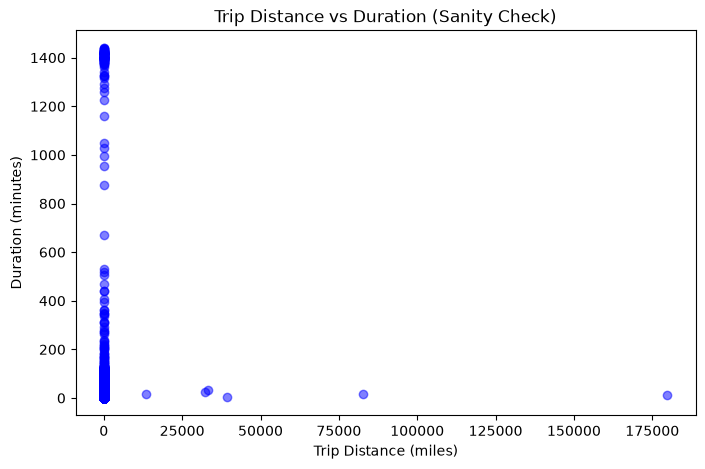

Top 20 extreme trip distances:


,trip_distance,duration
38985,179830.92,11.000000
39635,82698.45,15.000000
38509,39298.38,5.000000
38960,33216.30,35.000000
39062,32319.24,26.000000
35538,13439.72,16.000000
9765,213.72,221.500000
31403,76.94,467.700000
21024,75.00,395.400000
8790,54.25,117.450000


In [19]:
before_cleaning = len(df)
df = df[(df["trip_distance"] >= 0.1) & (df["duration"] >= 0.1)]
after_cleaning = len(df)
removed_rows = before_cleaning - after_cleaning
print(f"Removed records: {removed_rows}")
print(f"Remaining records: {after_cleaning}")
print(f"Percentage removed: {(removed_rows / before_cleaning) * 100:.2f}%\n")

plt.figure(figsize=(8, 5))
plt.scatter(df["trip_distance"], df["duration"], alpha=0.5, color='blue')
plt.xlabel("Trip Distance (miles)")
plt.ylabel("Duration (minutes)")
plt.title("Trip Distance vs Duration (Sanity Check)")
plt.show()

print("Top 20 extreme trip distances:")
display(df[['trip_distance', 'duration']].sort_values(by='trip_distance', ascending=False).head(20))

In [20]:
max_distance = df['trip_distance'].quantile(0.999)
max_duration = df['duration'].quantile(0.999)

print(f"99.9% of normal trips are under {max_distance:.2f} miles")
print(f"99.9% of normal trips take less than {max_duration:.2f} minutes\n")

df = df[(df["trip_distance"] <= max_distance) & (df["duration"] <= max_duration)]

print(f"Dataset shape after capping outliers: {df.shape}")

99.9% of normal trips are under 27.10 miles
99.9% of normal trips take less than 1410.58 minutes

Dataset shape after capping outliers: (38482, 7)


### 5. Data-Driven Outlier Capping (Upper Bounds)

Following the removal of unphysical lower-bound records, a visual inspection of the scatter plot and the top 20 extreme values revealed severe system anomalies at the upper bounds. 

**Observations:**
* **Extreme Distances:** Several records showed impossible distances (e.g., > 10,000 miles) which clearly indicate GPS or system malfunctions.
* **Extreme Durations:** Some trips recorded normal distances (e.g., 45 miles) but implausible durations (e.g., over 17 hours), likely due to unclosed taximeters.

**Methodology:**
Rather than applying arbitrary thresholds to cap these upper bounds, a statistical, data-driven approach was utilized. We calculated the **99.9th percentile** for both `trip_distance` and `duration` to establish the natural maximum limits of a legitimate New York City taxi trip. 

**Action:**
The dataset was filtered to exclude any records exceeding these 99.9% quantile thresholds, effectively removing system noise while preserving the natural right-skewed distribution of legitimate long-distance trips.

## Feature Engineering And Spliting

In [21]:
df["PU_DO"] = df["PULocationID"].astype(str) + "_" + df["DOLocationID"].astype(str)

In [22]:
X = df[["PU_DO", "trip_distance"]]
y = df["duration"]

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [24]:
categorical_features = ["PU_DO"]
numerical_features = ["trip_distance"]

preprocessor = ColumnTransformer(
    transformers=[
        ("categorical", OneHotEncoder(handle_unknown="ignore", sparse_output=True), categorical_features),
        ("numerical", "passthrough", numerical_features),
    ]
)
model_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression()),
    ]
)

In [25]:
model_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](2,)","['PU_DO','trip_distance']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,2
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('categorical', ...), ('numerical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of

In [26]:
predictions = model_pipeline.predict(X_test)
mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))

In [27]:
print(f"linear regression Baseline Performance:")
print(f"MAE: {mae:.4f} minutes")
print(f"RMSE: {rmse:.4f} minutes")

linear regression Baseline Performance:
MAE: 9.5424 minutes
RMSE: 63.0777 minutes


In [29]:
errors = y_test - predictions

In [30]:
np.abs(errors).describe()

count    7697.000000
mean        9.542381
std        62.355753
min         0.000534
25%         1.442339
50%         3.212290
75%         7.004270
max      1390.948965
Name: duration, dtype: float64

In [31]:
largest_errors = (
    pd.DataFrame({
        "actual": y_test,
        "predicted": predictions,
        "error": errors
    })
    .assign(abs_error=lambda x: x["error"].abs())
    .sort_values("abs_error", ascending=False)
)

largest_errors.head(20)

,actual,predicted,error,abs_error
10709,1401.366667,10.417701,1390.948965,1390.948965
30480,1402.916667,12.575464,1390.341203,1390.341203
22247,1397.966667,9.314297,1388.652369,1388.652369
30608,1399.916667,12.201773,1387.714894,1387.714894
19247,1395.866667,9.980110,1385.886557,1385.886557
33915,1395.016667,9.476811,1385.539855,1385.539855
24305,1403.683333,19.201962,1384.481371,1384.481371
26883,1399.416667,19.100344,1380.316322,1380.316322
230,1398.916667,19.836099,1379.080568,1379.080568
7620,1390.416667,12.507712,1377.908954,1377.908954
